# Detekcija lažnih oglasa za posao

Rad se bavi kvalitetom tekstualnih podataka na primeru binarne klasifikacije oglasa za posao na klase `real` i `fake`.

Rad prikazuje kako dužina i struktura dokumenata, prisustvo šuma, različiti postupci predobrade i izbor tekstualne reprezentacije utiču na podatke koji se prosleđuju modelima. Modeli mašinskog učenja koriste se za poređenje efekata predobrade i procenu pouzdanosti klasifikacije.

In [1]:
import contextlib
import io
import random
import time
import re
import string
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
from scipy.sparse import hstack

from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    precision_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

try:
    from gensim.models import FastText, Word2Vec
    GENSIM_AVAILABLE = True
except Exception:
    FastText = None
    Word2Vec = None
    GENSIM_AVAILABLE = False

try:
    import torch
    from transformers import AutoModel, AutoTokenizer
    from transformers.utils import logging as transformers_logging
    transformers_logging.set_verbosity_error()
    TRANSFORMERS_AVAILABLE = True
except Exception:
    torch = None
    AutoModel = None
    AutoTokenizer = None
    TRANSFORMERS_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
if TRANSFORMERS_AVAILABLE:
    torch.manual_seed(RANDOM_STATE)
    torch.set_num_threads(max(1, min(8, torch.get_num_threads())))

sns.set_theme(style="whitegrid")
print("Transformers dostupni:", TRANSFORMERS_AVAILABLE)
print("Gensim dostupan:", GENSIM_AVAILABLE)
if TRANSFORMERS_AVAILABLE:
    print("PyTorch:", torch.__version__)

Transformers dostupni: True
Gensim dostupan: True
PyTorch: 2.8.0


## 1. Učitavanje i osnovni pregled skupa podataka

Skup sadrži tekstualne i strukturirane podatke o oglasima za posao, kao i binarnu ciljnu promenljivu `is_fake`. Tekstualne kolone `job_title`, `job_description`, `requirements`, `benefits` i `company_profile` spajaju se u jedinstveno polje `full_text`, koje predstavlja osnovu za dalju obradu.

Početni pregled obuhvata dimenzije skupa, tipove podataka, nedostajuće vrednosti, raspodelu ciljnih klasa i prisustvo duplikata. Na taj način se pre predobrade dobija pregled strukture i osnovnih problema u podacima.

In [2]:
DATASET_PATH = "fake_real_job_postings.csv"

df = pd.read_csv(DATASET_PATH)

TEXT_COLUMNS = ["job_title", "job_description", "requirements", "benefits", "company_profile"]
TARGET = "is_fake"

df["full_text"] = df[TEXT_COLUMNS].fillna("").agg(" ".join, axis=1)
df["label"] = df[TARGET].map({0: "real", 1: "fake"})

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (3000, 27)


,job_id,job_title,job_description,requirements,benefits,company_name,company_profile,industry,employment_type,location,...,company_website,has_logo,num_open_positions,job_function,telecommuting,fraud_reason,text_length,is_fake,full_text,label
0,1,Data Analyst,Successful candidates communicate clearly with...,"THE WORK REQUIRES ATTENTION TO DETAIL, CLEAR H...","Bonus eligibility depends on team results, del...",BrightPath Solutions,Teams are small enough for direct collaboratio...,Software,Part-time,"Budapest, Hungary",...,https://www.brightpathsolutions.eu,1,3,Analysis,0,NaN,1634,0,Data Analyst Successful candidates communicate...,real
1,2,Content Strategist,"The work requires attention to detail, clear h...",Candidates should be comfortable learning inte...,Flexible working hours with agreed core collab...,OakLine Holdings,Our recruiters may represent more than one con...,Logistics,Internship,Remote,...,https://www.oaklineholdings.co,1,1,Design,1,NaN,1558,0,Content Strategist The work requires attention...,real
2,3,Data Analyst,Successful candidates communicate clearly with...,Candidates should be comfortable learning inte...,MANAGER SUPPORT DURING ONBOARDING AND ACCESS T...,SilverFern Holdings,The company builds long-term client relationsh...,Human Resources,Part-time,"Novi Sad, Serbia",...,https://www.silverfernholdings.eu,1,2,Analysis,0,NaN,1679,0,Data Analyst Successful candidates communicate...,real
3,4,Software Engineer,We are looking for someone who can balance day...,Our team works in short planning cycles and us...,"Bonus eligibility depends on team results, del...",OakLine Collective,Current growth has outpaced some internal syst...,Education,Full-time,"Berlin, Germany",...,https://www.oaklinecollective.eu,1,3,Development,0,NaN,1529,0,Software Engineer We are looking for someone w...,real
4,5,Data Analyst,Candidates should be comfortable learning inte...,You will partner with cross-functional te@mmat...,A mix of independent work and regular team che...,BlueCedar Solutions,Our Recruiters May Represent More Than One Con...,Education,Full-time,"Budapest, Hungary",...,https://www.bluecedarsolutions.rs,1,1,Analysis,0,NaN,1904,1,Data Analyst Candidates should be comfortable ...,fake


In [3]:
summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_percent": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(),
    }
).sort_values(["missing_percent", "unique_values"], ascending=[False, False])

display(summary)

,dtype,missing,missing_percent,unique_values
fraud_reason,str,2804,93.47,5
company_website,str,380,12.67,480
job_id,int64,0,0.00,3000
full_text,str,0,0.00,3000
job_description,str,0,0.00,2996
benefits,str,0,0.00,2862
requirements,str,0,0.00,2838
company_profile,str,0,0.00,2086
contact_email,str,0,0.00,1724
text_length,int64,0,0.00,1011


In [4]:
display(df[TARGET].value_counts().rename(index={0: "real", 1: "fake"}).to_frame("count"))

,count
is_fake,
real,1500
fake,1500


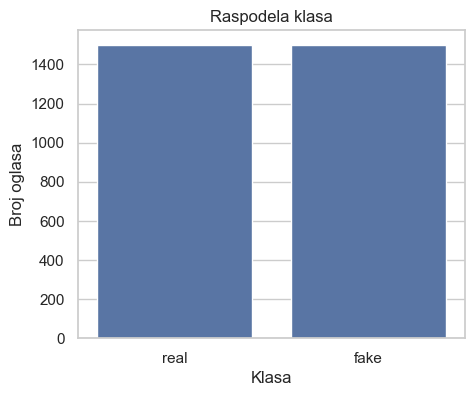

Duplicirani redovi: 0
Duplicirani full_text tekstovi: 0


In [5]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="label", order=["real", "fake"])
plt.title("Raspodela klasa")
plt.xlabel("Klasa")
plt.ylabel("Broj oglasa")
plt.show()

print("Duplicirani redovi:", df.duplicated().sum())
print("Duplicirani full_text tekstovi:", df["full_text"].duplicated().sum())


## 2. Kvalitet tekstualnih podataka

Kvalitet teksta posmatra se kroz dužinu dokumenata, veličinu rečnika, leksičku raznovrsnost i prisustvo šuma. Pokazatelji se računaju za svaki dokument, a zatim se porede između stvarnih i lažnih oglasa.

Analiziraju se tri grupe pokazatelja:

- **strukturne osobine**: broj karaktera, reči i rečenica, prosečna dužina reči i leksička raznovrsnost,
- **direktno uočljiv šum**: HTML, emoji simboli, URL i email adrese, brojevi, interpunkcija i velika slova,
- **indikatori nepravilnog teksta**: tipografske i OCR zamene, spam fraze i ponovljena interpunkcija.

Ove osobine opisuju razlike u načinu pisanja oglasa i omogućavaju da se kasnije proveri da li indikatori kvaliteta nose dodatnu informaciju za klasifikaciju.

In [6]:
WORD_RE = re.compile(r"\b[^\W\d_][\w@\-']*\b", re.UNICODE)
SENTENCE_RE = re.compile(r"(?<=[.!?])\s+")
HTML_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
EMAIL_RE = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")
EMOJI_RE = re.compile(
    "[" "\U0001F300-\U0001FAFF" "\U00002700-\U000027BF" "\U00002600-\U000026FF" "]",
    flags=re.UNICODE,
)
TYPO_RE = re.compile(r"\b\w*(?:[a-z][0@1][a-z]|[a-z]+[-@][a-z]+)\w*\b", re.I)
OCR_RE = re.compile(r"\b\w*(?:[a-z][01][a-z]|rn|cl)\w*\b", re.I)
SPAM_RE = re.compile(
    r"\b(?:urgent|immediate start|easy money|earn \$?|limited time|act now|no experience|"
    r"guaranteed income|wire transfer|crypto|whatsapp|telegram)\b", re.I
)


def word_tokens(text: str) -> list[str]:
    return WORD_RE.findall(str(text).lower())


def sentence_tokens(text: str) -> list[str]:
    return [s.strip() for s in SENTENCE_RE.split(str(text)) if s.strip()]


def lexical_diversity(tokens: list[str]) -> float:
    return len(set(tokens)) / len(tokens) if tokens else 0.0


def uppercase_ratio(text: str) -> float:
    chars = [ch for ch in str(text) if ch.isalpha()]
    return sum(ch.isupper() for ch in chars) / len(chars) if chars else 0.0


def punctuation_ratio(text: str) -> float:
    text = str(text)
    return sum(ch in string.punctuation for ch in text) / len(text) if text else 0.0


def non_ascii_ratio(text: str) -> float:
    text = str(text)
    return sum(ord(ch) > 127 for ch in text) / len(text) if text else 0.0


df["word_tokens"] = df["full_text"].apply(word_tokens)
df["char_length"] = df["full_text"].str.len()
df["word_count"] = df["word_tokens"].apply(len)
df["sentence_count"] = df["full_text"].apply(lambda x: len(sentence_tokens(x)))
df["avg_word_length"] = df["word_tokens"].apply(lambda x: np.mean([len(t) for t in x]) if x else 0)
df["lexical_diversity"] = df["word_tokens"].apply(lexical_diversity)
df["html_tag_count"] = df["full_text"].apply(lambda x: len(HTML_RE.findall(str(x))))
df["url_count"] = df["full_text"].apply(lambda x: len(URL_RE.findall(str(x))))
df["email_count"] = df["full_text"].apply(lambda x: len(EMAIL_RE.findall(str(x))))
df["emoji_count"] = df["full_text"].apply(lambda x: len(EMOJI_RE.findall(str(x))))
df["spam_phrase_count"] = df["full_text"].apply(lambda x: len(SPAM_RE.findall(str(x))))
df["repeated_punctuation_count"] = df["full_text"].str.count(r"[!?]{2,}")
df["digit_count"] = df["full_text"].apply(lambda x: sum(ch.isdigit() for ch in str(x)))
df["punctuation_ratio"] = df["full_text"].apply(punctuation_ratio)
df["uppercase_ratio"] = df["full_text"].apply(uppercase_ratio)
df["non_ascii_ratio"] = df["full_text"].apply(non_ascii_ratio)
df["typo_proxy_count"] = df["full_text"].apply(lambda x: len(TYPO_RE.findall(str(x))))
df["ocr_proxy_count"] = df["full_text"].apply(lambda x: len(OCR_RE.findall(str(x))))

QUALITY_COLUMNS = [
    "char_length", "word_count", "sentence_count", "avg_word_length",
    "lexical_diversity", "html_tag_count", "url_count", "email_count",
    "emoji_count", "spam_phrase_count", "repeated_punctuation_count",
    "digit_count", "punctuation_ratio", "uppercase_ratio", "non_ascii_ratio",
    "typo_proxy_count", "ocr_proxy_count",
]

In [7]:
display(df.groupby("label")[QUALITY_COLUMNS].mean().round(3).T)

label,fake,real
char_length,1959.599,1577.150
word_count,270.377,216.057
sentence_count,17.619,14.501
avg_word_length,6.088,6.126
lexical_diversity,0.636,0.662
html_tag_count,0.245,0.172
url_count,0.000,0.000
email_count,0.000,0.000
emoji_count,0.000,0.000
spam_phrase_count,0.329,0.034


In [8]:
noise_presence = pd.DataFrame({
    "noise_type": ["HTML", "emoji", "spam phrase", "repeated punctuation", "typo proxy", "OCR proxy"],
    "documents_with_noise": [
        (df["html_tag_count"] > 0).sum(), (df["emoji_count"] > 0).sum(),
        (df["spam_phrase_count"] > 0).sum(), (df["repeated_punctuation_count"] > 0).sum(),
        (df["typo_proxy_count"] > 0).sum(), (df["ocr_proxy_count"] > 0).sum(),
    ],
})
display(noise_presence)

,noise_type,documents_with_noise
0,HTML,306
1,emoji,0
2,spam phrase,489
3,repeated punctuation,0
4,typo proxy,2998
5,OCR proxy,3000


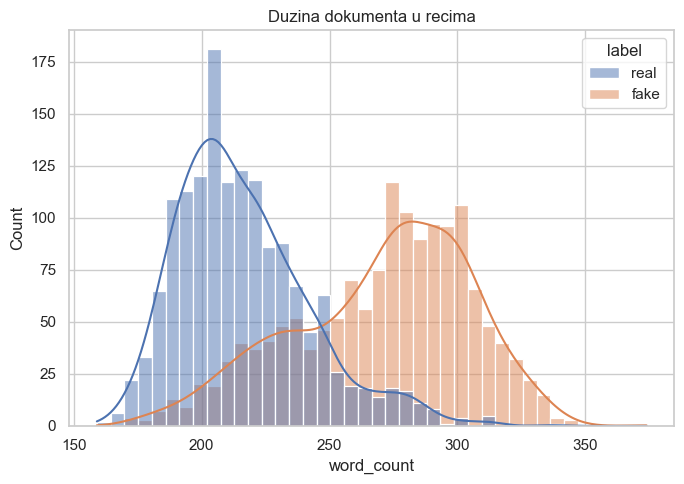

In [9]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="word_count", hue="label", bins=40, kde=True)
plt.title("Duzina dokumenta u recima")
plt.tight_layout()
plt.show()

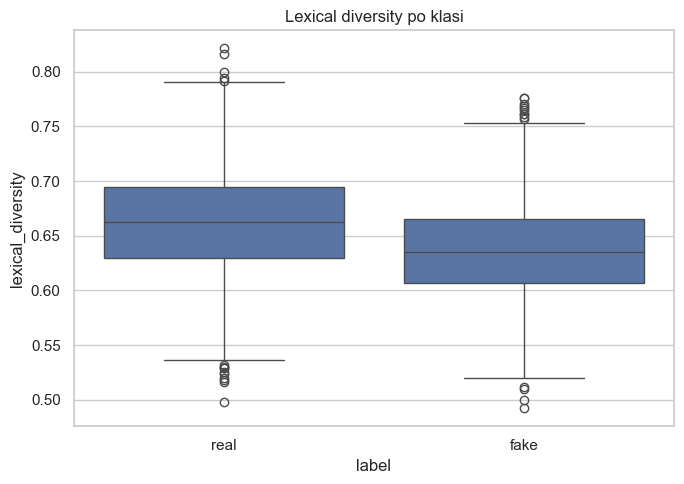

In [10]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="label", y="lexical_diversity", order=["real", "fake"])
plt.title("Lexical diversity po klasi")
plt.tight_layout()
plt.show()

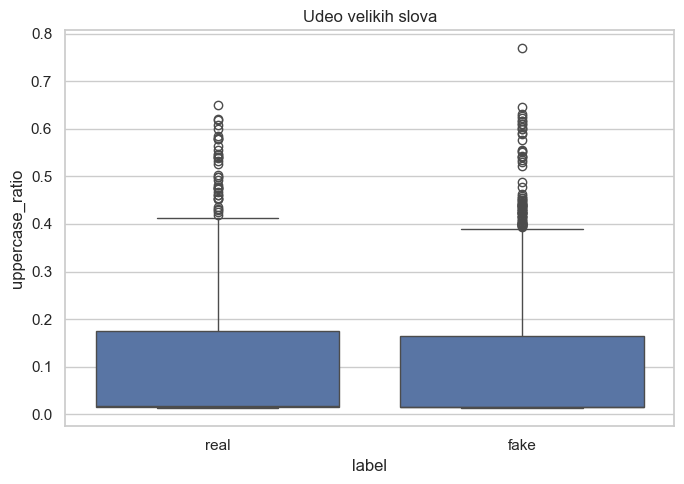

In [11]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="label", y="uppercase_ratio", order=["real", "fake"])
plt.title("Udeo velikih slova")
plt.tight_layout()
plt.show()

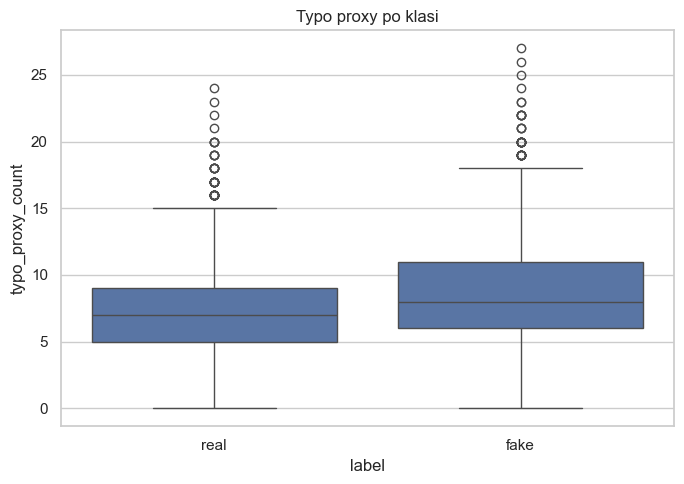

In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="label", y="typo_proxy_count", order=["real", "fake"])
plt.title("Typo proxy po klasi")
plt.tight_layout()
plt.show()

In [13]:
def vocabulary_stats(frame: pd.DataFrame, text_col: str) -> pd.DataFrame:
    rows = []
    for label, part in frame.groupby("label"):
        tokens = [token for tokens in part[text_col].apply(word_tokens) for token in tokens]
        counter = Counter(tokens)
        rows.append(
            {
                "class": label,
                "total_tokens": len(tokens),
                "vocabulary_size": len(counter),
                "hapax_tokens": sum(1 for value in counter.values() if value == 1),
                "top_10_tokens": ", ".join(token for token, _ in counter.most_common(10)),
            }
        )
    return pd.DataFrame(rows)


display(vocabulary_stats(df, "full_text"))


,class,total_tokens,vocabulary_size,hapax_tokens,top_10_tokens
0,fake,405566,1174,307,"and, the, to, with, a, are, in, may, internal,..."
1,real,324086,1155,292,"and, with, to, the, a, in, are, role, internal..."


## 3. Tokenizacija teksta

Tekst se može podeliti i posmatrati na više nivoa:

- **tokeni reči** predstavljaju osnovu za Bag of Words i TF-IDF reprezentacije,
- **tokeni rečenica** omogućavaju analizu strukture i dužine dokumenta,
- **subword tokeni** dele reči na manje delove i bolje obrađuju retke reči, tipografske greške i nepoznate oblike.

Subword pristup se praktično primenjuje kroz `character n-gram TF-IDF`. Dodatno se prikazuje kako tokenizer modela DistilBERT deli tekst na subword jedinice.

In [14]:
example_idx = 0
example_text = df.loc[example_idx, "full_text"]

def character_ngrams(text: str, n: int = 4, limit: int = 25) -> list[str]:
    compact = re.sub(r"\s+", " ", str(text).lower()).strip()
    grams = [compact[i : i + n] for i in range(max(0, len(compact) - n + 1))]
    return grams[:limit]


tokenization_preview = pd.DataFrame(
    {
        "word_tokens_first_25": [word_tokens(example_text)[:25]],
        "sentence_tokens_first_5": [sentence_tokens(example_text)[:5]],
        "char_4grams_first_25": [character_ngrams(example_text, n=4, limit=25)],
    }
).T

display(tokenization_preview)


,0
word_tokens_first_25,"[data, analyst, successful, candidates, commun..."
sentence_tokens_first_5,[Data Analyst Successful candidates communicat...
char_4grams_first_25,"[data, ata , ta a, a an, ana, anal, naly, aly..."


### 3.1 Subword tokenizacija na primeru prethodno obučenog tokenizer-a

Subword tokenizacija omogućava da model obradi reč i kada je ne poznaje kao celinu. Deljenjem na manje jedinice čuva se deo informacije i kod retkih, nepravilnih ili izmenjenih oblika reči.

Subword tokenizacija prikazana je pomoću tokenizer-a prethodno obučenog modela DistilBERT. Njegov izlaz pokazuje razliku između tokenizacije celih reči i tokenizacije zasnovane na manjim delovima reči.

In [15]:
subword_examples = ["communication", "communicat1on", "applicants", "unseenword"]

try:
    demo_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased", local_files_only=True)
    subword_preview = pd.DataFrame({
        "word": subword_examples,
        "word_tokens": [word_tokens(word) for word in subword_examples],
        "char_4grams": [character_ngrams(word, n=4, limit=8) for word in subword_examples],
        "distilbert_subwords": [demo_tokenizer.tokenize(word) for word in subword_examples],
    })
except Exception as exc:
    subword_preview = pd.DataFrame({
        "word": subword_examples,
        "word_tokens": [word_tokens(word) for word in subword_examples],
        "char_4grams": [character_ngrams(word, n=4, limit=8) for word in subword_examples],
        "distilbert_subwords": ["tokenizer nije lokalno dostupan"] * len(subword_examples),
    })


display(subword_preview)


,word,word_tokens,char_4grams,distilbert_subwords
0,communication,[communication],"[comm, ommu, mmun, muni, unic, nica, icat, cati]",[communication]
1,communicat1on,[communicat1on],"[comm, ommu, mmun, muni, unic, nica, icat, cat1]","[com, ##mun, ##ica, ##t, ##1, ##on]"
2,applicants,[applicants],"[appl, ppli, plic, lica, ican, cant, ants]",[applicants]
3,unseenword,[unseenword],"[unse, nsee, seen, eenw, enwo, nwor, word]","[unseen, ##word]"


## 4. Predobrada teksta

Od početnog teksta formira se pet verzija podataka:

- `raw_text`: originalni spojeni tekst oglasa,
- `normalized_text`: tekst nakon uklanjanja HTML-a, URL i email adresa, brojeva, interpunkcije i emoji simbola, uz NFKC Unicode normalizaciju i pretvaranje u mala slova,
- `no_stopwords_text`: normalizovan tekst bez engleskih stop-reči,
- `stemmed_text`: tekst obrađen Porter stemmerom,
- `lemmatized_text`: tekst obrađen WordNet lematizatorom.

Stemming agresivnije svodi reči na zajedničku osnovu, dok lematizacija pokušava da sačuva pravilan osnovni oblik reči. Promena broja tokena i veličine rečnika koristi se za poređenje posledica svakog postupka predobrade.

In [16]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


def strip_html(text: str) -> str:
    return BeautifulSoup(str(text), "html.parser").get_text(" ")


def normalize_text(text: str) -> str:
    text = strip_html(text)
    text = unicodedata.normalize("NFKC", str(text)).casefold()
    text = URL_RE.sub(" ", text)
    text = EMAIL_RE.sub(" ", text)
    text = EMOJI_RE.sub(" ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    return re.sub(r"\s+", " ", text).strip()


def remove_stopwords(text: str) -> str:
    return " ".join(t for t in str(text).split() if t not in ENGLISH_STOP_WORDS)


def stem_text(text: str) -> str:
    return " ".join(stemmer.stem(t) for t in str(text).split())


def lemmatize_text(text: str) -> str:
    return " ".join(lemmatizer.lemmatize(t) for t in str(text).split())


df["raw_text"] = df["full_text"]
df["normalized_text"] = df["raw_text"].apply(normalize_text)
df["no_stopwords_text"] = df["normalized_text"].apply(remove_stopwords)
df["stemmed_text"] = df["no_stopwords_text"].apply(stem_text)
df["lemmatized_text"] = df["no_stopwords_text"].apply(lemmatize_text)

display(pd.DataFrame({
    c: [df.loc[0, c][:260]]
    for c in ["raw_text", "normalized_text", "no_stopwords_text", "stemmed_text", "lemmatized_text"]
}).T)

,0
raw_text,Data Analyst Successful candidates communicate...
normalized_text,data analyst successful candidates communicate...
no_stopwords_text,data analyst successful candidates communicate...
stemmed_text,data analyst success candid commun clearli sta...
lemmatized_text,data analyst successful candidate communicate ...


In [17]:
preprocessing_stats = []
for column in ["raw_text", "normalized_text", "no_stopwords_text", "stemmed_text", "lemmatized_text"]:
    tokens = [token for text in df[column] for token in str(text).split()]
    preprocessing_stats.append(
        {
            "text_variant": column,
            "total_tokens": len(tokens),
            "vocabulary_size": len(set(tokens)),
            "avg_tokens_per_doc": round(np.mean([len(str(text).split()) for text in df[column]]), 2),
        }
    )

display(pd.DataFrame(preprocessing_stats))


,text_variant,total_tokens,vocabulary_size,avg_tokens_per_doc
0,raw_text,747050,2659,249.02
1,normalized_text,733301,483,244.43
2,no_stopwords_text,487747,412,162.58
3,stemmed_text,487747,347,162.58
4,lemmatized_text,487747,394,162.58


## 5. Kontrolisana augmentacija trening teksta

Augmentacija se koristi za proveru da li male promene teksta mogu da povećaju raznovrsnost trening podataka uz očuvanu ciljnu klasu.

Primenjuju se dve kontrolisane transformacije:

- zamena malog broja čestih domenskih reči sinonimima,
- uklanjanje malog broja tokena.

Transformacije se primenjuju samo na trening podatke, dok test skup ostaje neizmenjen. Time se rezultat i dalje meri nad istim originalnim primerima.

In [18]:
SYNONYMS = {
    "job": ["position", "role"],
    "role": ["position", "job"],
    "team": ["group", "staff"],
    "candidate": ["applicant"],
    "candidates": ["applicants"],
    "company": ["organization"],
    "work": ["tasks"],
    "remote": ["online"],
    "support": ["assist"],
    "communication": ["collaboration"],
    "skills": ["abilities"],
    "experience": ["background"],
}


def augment_text(text: str, rng: random.Random, replacement_prob: float = 0.12, deletion_prob: float = 0.03) -> str:
    augmented = []
    for token in str(text).split():
        if rng.random() < deletion_prob and len(token) > 3:
            continue
        if token in SYNONYMS and rng.random() < replacement_prob:
            augmented.append(rng.choice(SYNONYMS[token]))
        else:
            augmented.append(token)
    return " ".join(augmented)


example_augmented = augment_text(df.loc[0, "normalized_text"], random.Random(RANDOM_STATE))
display(pd.DataFrame({"original": [df.loc[0, "normalized_text"][:260]], "augmented": [example_augmented[:260]]}).T)


,0
original,data analyst successful candidates communicate...
augmented,data successful candidates communicate clearly...


### 5.1 Kontrolisano dodavanje šuma

Za proveru robusnosti formira se dodatna verzija test teksta sa jednostavnim oblicima šuma: HTML oznakom, spam frazom i manjim brojem tipografskih ili OCR zamena.

Poređenjem rezultata na originalnom i izmenjenom test skupu meri se koliko je model osetljiv na pad kvaliteta ulaznog teksta.

In [19]:
def inject_noise(text, rng):
    tokens = str(text).split()
    noisy = []
    for token in tokens:
        if len(token) > 5 and rng.random() < 0.035:
            pos = rng.randrange(1, len(token) - 1)
            token = token[:pos] + rng.choice(["0", "1", "@"]) + token[pos + 1:]
        noisy.append(token)
    return "<div>" + " ".join(noisy) + "</div> ACT NOW!!!"


noise_rng = random.Random(RANDOM_STATE)
noise_preview = inject_noise(df.loc[0, "full_text"][:300], noise_rng)
display(pd.DataFrame({"clean": [df.loc[0, "full_text"][:300]], "noisy": [noise_preview]}).T)


,0
clean,Data Analyst Successful candidates communicate...
noisy,<div>Data Analyst Succe0sful candidates commun...


## 6. Klasične tekstualne reprezentacije i modeli

U modelskom delu porede se reprezentacije koje na različite načine pretvaraju tekst u numeričke podatke:

- **Bag of Words** broji pojavljivanja reči i fraza,
- **word TF-IDF** daje veću težinu rečima koje su karakteristične za dokument,
- **character n-gram TF-IDF** posmatra delove reči i otporniji je na manje greške u pisanju,
- **TF-IDF sa indikatorima kvaliteta** kombinuje sadržaj teksta sa prethodno izmerenim osobinama kvaliteta,
- **LSA** formira kompaktniju reprezentaciju početne TF-IDF matrice.

Konfiguracije se porede pomoću tačnosti, preciznosti, odziva i F1 mere. F1 mera je posebno važna jer istovremeno uzima u obzir preciznost i odziv pri prepoznavanju lažnih oglasa.

In [20]:
print("Glavni deo projekta koristi scikit-learn modele i vektorske reprezentacije teksta.")
print("DistilBERT deo je izdvojen kao napredni dodatak i koristi lokalno dostupne pretrained težine, ako postoje.")

Glavni deo projekta koristi scikit-learn modele i vektorske reprezentacije teksta.
DistilBERT deo je izdvojen kao napredni dodatak i koristi lokalno dostupne pretrained težine, ako postoje.


In [21]:
y = df[TARGET].astype(int)
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Test class distribution:")
display(y.loc[test_idx].value_counts().sort_index().rename(index={0: "real", 1: "fake"}).to_frame("count"))


Train size: 2400
Test size: 600
Test class distribution:


,count
is_fake,
real,300
fake,300


In [22]:
def build_vectorizer(kind: str):
    if kind == "bow":
        return CountVectorizer(max_features=8000, ngram_range=(1, 2), min_df=2)
    if kind == "tfidf_word":
        return TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=2, sublinear_tf=True, strip_accents="unicode")
    if kind == "tfidf_char":
        return TfidfVectorizer(max_features=12000, analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True)
    raise ValueError(f"Nepoznata reprezentacija: {kind}")


def build_estimator(model_name: str):
    if model_name == "LogisticRegression":
        return LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)
    if model_name == "LinearSVC":
        return LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)
    if model_name == "MultinomialNB":
        return MultinomialNB()
    raise ValueError(f"Nepoznat model: {model_name}")


def augment_training_set(texts: pd.Series, labels: pd.Series) -> tuple[pd.Series, pd.Series]:
    rng = random.Random(RANDOM_STATE)
    augmented_texts = texts.apply(lambda text: augment_text(text, rng))
    return pd.concat([texts, augmented_texts], ignore_index=True), pd.concat([labels, labels], ignore_index=True)


def evaluate_config(config: dict) -> dict:
    text_col = config["text_col"]
    X_train = df.loc[train_idx, text_col].astype(str)
    X_test = df.loc[test_idx, text_col].astype(str)
    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    if config.get("augment", False):
        X_train, y_train = augment_training_set(X_train.reset_index(drop=True), y_train.reset_index(drop=True))

    if config.get("dense_lsa", False):
        estimator = Pipeline(
            [
                ("tfidf", build_vectorizer("tfidf_word")),
                ("svd", TruncatedSVD(n_components=120, random_state=RANDOM_STATE)),
                ("clf", build_estimator(config["model"])),
            ]
        )
        estimator.fit(X_train, y_train)
        y_pred = estimator.predict(X_test)
        fitted = estimator
    else:
        vectorizer = build_vectorizer(config["vectorizer"])
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)

        scaler = None
        if config.get("quality_features", False):
            scaler = StandardScaler()
            train_quality = scaler.fit_transform(df.loc[train_idx, QUALITY_COLUMNS])
            test_quality = scaler.transform(df.loc[test_idx, QUALITY_COLUMNS])
            if config.get("augment", False):
                train_quality = np.vstack([train_quality, train_quality])
            X_train_vec = hstack([X_train_vec, train_quality])
            X_test_vec = hstack([X_test_vec, test_quality])

        estimator = build_estimator(config["model"])
        estimator.fit(X_train_vec, y_train)
        y_pred = estimator.predict(X_test_vec)
        fitted = {"vectorizer": vectorizer, "model": estimator, "scaler": scaler}

    return {
        "experiment": config["name"],
        "text_variant": text_col,
        "representation": config.get("representation", config.get("vectorizer", "dense_lsa")),
        "model": config["model"],
        "augmented_train": config.get("augment", False),
        "quality_features": config.get("quality_features", False),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, target_names=["real", "fake"], zero_division=0),
        "y_pred": y_pred,
        "fitted": fitted,
    }


In [23]:
EXPERIMENTS = [
    {"name": "BoW raw + LogisticRegression", "text_col": "raw_text", "vectorizer": "bow", "representation": "Bag of Words", "model": "LogisticRegression"},
    {"name": "BoW normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "bow", "representation": "Bag of Words", "model": "LogisticRegression"},
    {"name": "TF-IDF raw + LogisticRegression", "text_col": "raw_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF stemmed + LogisticRegression", "text_col": "stemmed_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF lemmatized + LogisticRegression", "text_col": "lemmatized_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF stemmed + MultinomialNB", "text_col": "stemmed_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "MultinomialNB"},
    {"name": "TF-IDF normalized + LinearSVC", "text_col": "normalized_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LinearSVC"},
    {"name": "Subword char ngrams + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_char", "representation": "Character n-gram TF-IDF", "model": "LogisticRegression"},
    {"name": "Subword char ngrams + LinearSVC", "text_col": "normalized_text", "vectorizer": "tfidf_char", "representation": "Character n-gram TF-IDF", "model": "LinearSVC"},
    {"name": "TF-IDF stemmed + quality features", "text_col": "stemmed_text", "vectorizer": "tfidf_word", "representation": "TF-IDF + quality metrics", "model": "LogisticRegression", "quality_features": True},
    {"name": "Dense LSA baseline + LogisticRegression", "text_col": "normalized_text", "representation": "Dense LSA baseline", "model": "LogisticRegression", "dense_lsa": True},
    {"name": "Augmented TF-IDF normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_word", "representation": "TF-IDF with train augmentation", "model": "LogisticRegression", "augment": True},
]

results = [evaluate_config(config) for config in EXPERIMENTS]
results_df = pd.DataFrame(
    [{key: value for key, value in row.items() if key not in {"confusion_matrix", "classification_report", "y_pred", "fitted"}} for row in results]
).sort_values("f1", ascending=False)

display(results_df.reset_index(drop=True))


,experiment,text_variant,representation,model,augmented_train,quality_features,accuracy,precision,recall,f1
0,Subword char ngrams + LogisticRegression,normalized_text,Character n-gram TF-IDF,LogisticRegression,False,False,0.823333,0.854015,0.780000,0.815331
1,Subword char ngrams + LinearSVC,normalized_text,Character n-gram TF-IDF,LinearSVC,False,False,0.821667,0.848375,0.783333,0.814558
2,TF-IDF raw + LogisticRegression,raw_text,TF-IDF word ngrams,LogisticRegression,False,False,0.820000,0.842857,0.786667,0.813793
3,TF-IDF stemmed + LogisticRegression,stemmed_text,TF-IDF word ngrams,LogisticRegression,False,False,0.820000,0.842857,0.786667,0.813793
4,Dense LSA baseline + LogisticRegression,normalized_text,Dense LSA baseline,LogisticRegression,False,False,0.820000,0.842857,0.786667,0.813793
5,TF-IDF stemmed + MultinomialNB,stemmed_text,TF-IDF word ngrams,MultinomialNB,False,False,0.823333,0.864662,0.766667,0.812721
6,Augmented TF-IDF normalized + LogisticRegression,normalized_text,TF-IDF with train augmentation,LogisticRegression,True,False,0.813333,0.819728,0.803333,0.811448
7,TF-IDF normalized + LogisticRegression,normalized_text,TF-IDF word ngrams,LogisticRegression,False,False,0.816667,0.836879,0.786667,0.810997
8,TF-IDF lemmatized + LogisticRegression,lemmatized_text,TF-IDF word ngrams,LogisticRegression,False,False,0.816667,0.836879,0.786667,0.810997
9,TF-IDF stemmed + quality features,stemmed_text,TF-IDF + quality metrics,LogisticRegression,False,True,0.811667,0.816949,0.803333,0.810084


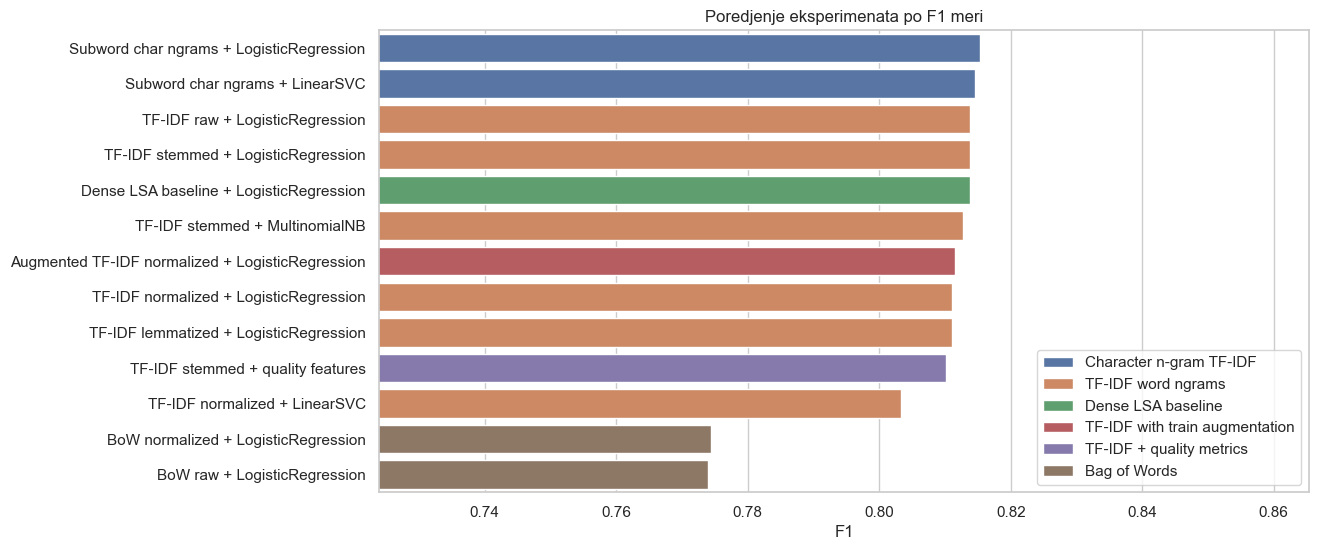

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="f1", y="experiment", hue="representation", dodge=False)
plt.title("Poredjenje eksperimenata po F1 meri")
plt.xlabel("F1")
plt.ylabel("")
plt.xlim(max(0, results_df["f1"].min() - 0.05), min(1, results_df["f1"].max() + 0.05))
plt.legend(loc="lower right")
plt.show()


## 7. Unakrsna validacija

Rezultat jednog train/test deljenja može zavisiti od konkretnih dokumenata koji se nađu u test skupu. Zbog toga se najvažnije konfiguracije dodatno proveravaju stratifikovanom petostrukom unakrsnom validacijom.

Srednje vrednosti F1 mere daju stabilniju procenu performansi, dok standardne devijacije pokazuju koliko rezultat zavisi od promene trening i validacionih podskupova.

In [25]:
CV_EXPERIMENTS = [
    {"name": "BoW normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "bow", "model": "LogisticRegression"},
    {"name": "TF-IDF raw + LogisticRegression", "text_col": "raw_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "TF-IDF normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "TF-IDF stemmed + LogisticRegression", "text_col": "stemmed_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "TF-IDF normalized + LinearSVC", "text_col": "normalized_text", "vectorizer": "tfidf_word", "model": "LinearSVC"},
    {"name": "Subword char ngrams + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_char", "model": "LogisticRegression"},
    {"name": "Subword char ngrams + LinearSVC", "text_col": "normalized_text", "vectorizer": "tfidf_char", "model": "LinearSVC"},
    {"name": "Dense LSA baseline + LogisticRegression", "text_col": "normalized_text", "model": "LogisticRegression", "dense_lsa": True},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1"}

cv_rows = []
for config in CV_EXPERIMENTS:
    if config.get("dense_lsa", False):
        estimator = Pipeline(
            [
                ("tfidf", build_vectorizer("tfidf_word")),
                ("svd", TruncatedSVD(n_components=120, random_state=RANDOM_STATE)),
                ("clf", build_estimator(config["model"])),
            ]
        )
    else:
        estimator = Pipeline(
            [
                ("vectorizer", build_vectorizer(config["vectorizer"])),
                ("clf", build_estimator(config["model"])),
            ]
        )

    scores = cross_validate(estimator, df[config["text_col"]], y, cv=cv, scoring=scoring)
    cv_rows.append(
        {
            "experiment": config["name"],
            "accuracy_mean": scores["test_accuracy"].mean(),
            "accuracy_std": scores["test_accuracy"].std(),
            "precision_mean": scores["test_precision"].mean(),
            "recall_mean": scores["test_recall"].mean(),
            "f1_mean": scores["test_f1"].mean(),
            "f1_std": scores["test_f1"].std(),
        }
    )

cv_results_df = pd.DataFrame(cv_rows).sort_values("f1_mean", ascending=False)
display(cv_results_df.round(4).reset_index(drop=True))


,experiment,accuracy_mean,accuracy_std,precision_mean,recall_mean,f1_mean,f1_std
0,TF-IDF normalized + LogisticRegression,0.8343,0.0128,0.8979,0.7547,0.8198,0.0162
1,TF-IDF stemmed + LogisticRegression,0.8337,0.0127,0.8990,0.7520,0.8187,0.0157
2,TF-IDF raw + LogisticRegression,0.8333,0.0128,0.8971,0.7533,0.8186,0.0162
3,Subword char ngrams + LinearSVC,0.8330,0.0110,0.9002,0.7493,0.8176,0.0141
4,Dense LSA baseline + LogisticRegression,0.8327,0.0116,0.9001,0.7487,0.8172,0.0144
5,TF-IDF normalized + LinearSVC,0.8240,0.0128,0.8532,0.7833,0.8162,0.0166
6,Subword char ngrams + LogisticRegression,0.8317,0.0110,0.9005,0.7460,0.8157,0.0140
7,BoW normalized + LogisticRegression,0.7853,0.0182,0.7944,0.7700,0.7817,0.0214


## 8. Vektorske reprezentacije Word2Vec i FastText

Word2Vec i FastText predstavljaju dodatni način pretvaranja teksta u numeričke podatke. Vektori reči uče se samo iz trening tekstova, a svaki oglas se zatim predstavlja prosekom vektora svojih tokena.

Razlika između ova dva pristupa je sledeća:

- **Word2Vec** uči jedan vektor za celu reč na osnovu konteksta u kome se ona pojavljuje,
- **FastText** koristi i karakter n-grame, pa može bolje da obradi retke, izmenjene i prethodno nepoznate oblike reči.

Dobijene reprezentacije koriste se kao ulaz za logističku regresiju i porede se sa rezultatima TF-IDF modela.

In [26]:
def token_lists(series: pd.Series) -> list[list[str]]:
    return [str(text).split() for text in series]


def average_word_vectors(model, tokenized_texts: list[list[str]]) -> np.ndarray:
    vectors = []
    size = model.vector_size
    for tokens in tokenized_texts:
        known_vectors = [model.wv[token] for token in tokens if token in model.wv]
        if known_vectors:
            vectors.append(np.mean(known_vectors, axis=0))
        else:
            vectors.append(np.zeros(size))
    return np.vstack(vectors)


def evaluate_embedding_model(name: str, embedding_model) -> dict:
    X_train_emb = average_word_vectors(embedding_model, train_tokens)
    X_test_emb = average_word_vectors(embedding_model, test_tokens)

    clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(X_train_emb, y.loc[train_idx])
    y_pred = clf.predict(X_test_emb)

    return {
        "representation": name,
        "accuracy": accuracy_score(y.loc[test_idx], y_pred),
        "precision": precision_score(y.loc[test_idx], y_pred, zero_division=0),
        "recall": recall_score(y.loc[test_idx], y_pred, zero_division=0),
        "f1": f1_score(y.loc[test_idx], y_pred, zero_division=0),
    }

embedding_results = []

if not GENSIM_AVAILABLE:
    print("Gensim nije dostupan, pa se Word2Vec/FastText sekcija preskače.")
else:
    train_tokens = token_lists(df.loc[train_idx, "normalized_text"])
    test_tokens = token_lists(df.loc[test_idx, "normalized_text"])

    with contextlib.redirect_stderr(io.StringIO()):
        word2vec_model = Word2Vec(
            sentences=train_tokens,
            vector_size=80,
            window=5,
            min_count=2,
            workers=1,
            sg=1,
            epochs=15,
            seed=RANDOM_STATE,
        )

        fasttext_model = FastText(
            sentences=train_tokens,
            vector_size=80,
            window=5,
            min_count=2,
            workers=1,
            sg=1,
            epochs=15,
            min_n=3,
            max_n=5,
            seed=RANDOM_STATE,
        )

    embedding_results.append(evaluate_embedding_model("Word2Vec + avg vectors + LogisticRegression", word2vec_model))
    embedding_results.append(evaluate_embedding_model("FastText + avg vectors + LogisticRegression", fasttext_model))

embedding_results_df = pd.DataFrame(embedding_results)
if len(embedding_results_df):
    display(embedding_results_df.round(4).sort_values("f1", ascending=False))



,representation,accuracy,precision,recall,f1
0,Word2Vec + avg vectors + LogisticRegression,0.825,0.8598,0.7767,0.8161
1,FastText + avg vectors + LogisticRegression,0.820,0.8529,0.7733,0.8112


### 8.1 Tumačenje vektorskih reprezentacija

Stabilnost naučenih semantičkih vektora zavisi od količine i raznovrsnosti dostupnog teksta. Zbog toga se rezultati Word2Vec i FastText pristupa posmatraju zajedno sa veličinom korišćenog korpusa.

Njihova uloga u ovom radu je da prikažu drugačiju reprezentaciju podataka: dokument se ne opisuje samo frekvencijom tokena, već prosekom vektora naučenih iz njihovog konteksta. FastText dodatno pokazuje kako subword informacije mogu da sačuvaju signal kod retkih reči i manjih grešaka u pisanju.

## 9. Prethodno obučene Transformer reprezentacije

DistilBERT se koristi kao prethodno obučeni model koji tekst oglasa pretvara u guste vektorske reprezentacije. Na taj način se njegova reprezentacija može uporediti sa Bag of Words, TF-IDF, Word2Vec i FastText pristupima.

Postupak se sastoji iz tri koraka:

1. tekst se deli na tokene pomoću DistilBERT tokenizer-a,
2. DistilBERT izračunava vektorsku reprezentaciju teksta,
3. nad dobijenim vektorima trenira se klasifikator logističke regresije.

Ovaj eksperiment proverava da li prethodno naučene jezičke reprezentacije daju prednost u odnosu na reprezentacije izvedene direktno iz posmatranog skupa podataka.

In [27]:
best_classical = results_df.iloc[0]

display(pd.DataFrame([
    {
        "best_classical_experiment": best_classical["experiment"],
        "representation": best_classical["representation"],
        "model": best_classical["model"],
        "f1": best_classical["f1"],
    }
]).round(4))


,best_classical_experiment,representation,model,f1
0,Subword char ngrams + LogisticRegression,Character n-gram TF-IDF,LogisticRegression,0.8153


### 9.1 DistilBERT kao generator tekstualnih atributa

Koristi se prethodno obučeni model `distilbert-base-uncased`, čiji se parametri ne menjaju tokom eksperimenta. Model služi za izdvajanje numeričkih atributa iz teksta.

Logistička regresija se zatim trenira nad tim atributima, pa se njen rezultat može direktno porediti sa ostalim reprezentacijama korišćenim u radu.

In [28]:
DISTILBERT_MODEL = "distilbert-base-uncased"
DISTILBERT_MAX_LENGTH = 192
DISTILBERT_BATCH_SIZE = 16

distilbert_result = None

if not TRANSFORMERS_AVAILABLE:
    print("Transformers/PyTorch nisu dostupni, pa se DistilBERT dodatak preskače.")
else:
    DISTILBERT_DEVICE = torch.device("cpu")
    bert_texts = df[TEXT_COLUMNS].fillna("").agg(" [SEP] ".join, axis=1).astype(str)

    def distilbert_embeddings(texts: pd.Series, tokenizer, model, batch_size: int = DISTILBERT_BATCH_SIZE) -> np.ndarray:
        vectors = []
        model.eval()
        with torch.no_grad():
            for start in range(0, len(texts), batch_size):
                batch = texts.iloc[start:start + batch_size].tolist()
                encoded = tokenizer(
                    batch,
                    padding=True,
                    truncation=True,
                    max_length=DISTILBERT_MAX_LENGTH,
                    return_tensors="pt",
                )
                encoded = {key: value.to(DISTILBERT_DEVICE) for key, value in encoded.items()}
                output = model(**encoded)
                cls_vectors = output.last_hidden_state[:, 0, :].cpu().numpy()
                vectors.append(cls_vectors)
        return np.vstack(vectors)

    try:
        tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL, local_files_only=True)
        transformer = AutoModel.from_pretrained(DISTILBERT_MODEL, local_files_only=True).to(DISTILBERT_DEVICE)

        start_time = time.time()
        X_train_bert = distilbert_embeddings(bert_texts.loc[train_idx], tokenizer, transformer)
        X_test_bert = distilbert_embeddings(bert_texts.loc[test_idx], tokenizer, transformer)

        bert_clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
        bert_clf.fit(X_train_bert, y.loc[train_idx])
        bert_pred = bert_clf.predict(X_test_bert)

        distilbert_result = {
            "representation": "DistilBERT embeddings + LogisticRegression",
            "accuracy": accuracy_score(y.loc[test_idx], bert_pred),
            "precision": precision_score(y.loc[test_idx], bert_pred, zero_division=0),
            "recall": recall_score(y.loc[test_idx], bert_pred, zero_division=0),
            "f1": f1_score(y.loc[test_idx], bert_pred, zero_division=0),
            "runtime_minutes": (time.time() - start_time) / 60,
        }
        print("DistilBERT embeddings shape:", X_train_bert.shape)
    except Exception as exc:
        print("DistilBERT model nije lokalno dostupan ili nije mogao da se učita.")
        print("Razlog:", type(exc).__name__, str(exc)[:240])


DistilBERT embeddings shape: (2400, 768)


In [29]:
if distilbert_result is not None:
    display(pd.DataFrame([distilbert_result]).round(4))
else:
    print("DistilBERT rezultat nije dodat jer model nije lokalno dostupan.")


,representation,accuracy,precision,recall,f1,runtime_minutes
0,DistilBERT embeddings + LogisticRegression,0.8083,0.79,0.84,0.8142,0.8049


In [30]:
advanced_rows = [
    {
        "approach": "Najbolji klasični model",
        "representation": best_classical["representation"],
        "f1": best_classical["f1"],
    }
]

if len(embedding_results_df):
    best_embedding = embedding_results_df.sort_values("f1", ascending=False).iloc[0]
    advanced_rows.append(
        {
            "approach": "Najbolji word embedding model",
            "representation": best_embedding["representation"],
            "f1": best_embedding["f1"],
        }
    )

if distilbert_result is not None:
    advanced_rows.append(
        {
            "approach": "Pretrained Transformer dodatak",
            "representation": distilbert_result["representation"],
            "f1": distilbert_result["f1"],
        }
    )

advanced_comparison = pd.DataFrame(advanced_rows).sort_values("f1", ascending=False)
display(advanced_comparison.round(4))


,approach,representation,f1
1,Najbolji word embedding model,Word2Vec + avg vectors + LogisticRegression,0.8161
0,Najbolji klasični model,Character n-gram TF-IDF,0.8153
2,Pretrained Transformer dodatak,DistilBERT embeddings + LogisticRegression,0.8142


### 9.2 Tumačenje DistilBERT eksperimenta

DistilBERT rezultat predstavlja poređenje prethodno naučene jezičke reprezentacije sa reprezentacijama formiranim iz ovog skupa. Ako TF-IDF modeli ostvare sličan ili bolji rezultat, to pokazuje da su leksički obrasci u oglasima dovoljno izraženi i da klasične reprezentacije mogu biti konkurentne na posmatranom zadatku.

In [31]:
print("Najbolji klasični eksperiment:", best_classical["experiment"])
print("F1 najboljeg klasičnog eksperimenta:", round(best_classical["f1"], 4))

if len(embedding_results_df):
    best_embedding = embedding_results_df.sort_values("f1", ascending=False).iloc[0]
    print("Najbolji embedding eksperiment:", best_embedding["representation"])
    print("F1 najboljeg embedding eksperimenta:", round(best_embedding["f1"], 4))

if distilbert_result is not None:
    print("F1 DistilBERT dodatka:", round(distilbert_result["f1"], 4))
else:
    print("DistilBERT dodatak nije izvršen u ovom okruženju.")


Najbolji klasični eksperiment: Subword char ngrams + LogisticRegression
F1 najboljeg klasičnog eksperimenta: 0.8153
Najbolji embedding eksperiment: Word2Vec + avg vectors + LogisticRegression
F1 najboljeg embedding eksperimenta: 0.8161
F1 DistilBERT dodatka: 0.8142


### 9.3 Robusnost na HTML, tipografski i spam šum

Word TF-IDF i character n-gram TF-IDF modeli treniraju se na istim čistim dokumentima. F1 mera se zatim računa na originalnom i kontrolisano izmenjenom test skupu.

Razlika između dve F1 vrednosti predstavlja pad performansi usled šuma. Character n-gram reprezentacija posmatra delove reči, pa deo signala može ostati očuvan i kada se zapis reči promeni.

In [32]:
noisy_test = pd.Series(
    [inject_noise(t, random.Random(RANDOM_STATE + i)) for i, t in enumerate(df.loc[test_idx, "raw_text"])],
    index=test_idx,
)
robustness_rows = []
for name, vectorizer in [
    ("Word TF-IDF", build_vectorizer("tfidf_word")),
    ("Character subword TF-IDF", build_vectorizer("tfidf_char")),
]:
    Xtr = vectorizer.fit_transform(df.loc[train_idx, "raw_text"])
    clean = vectorizer.transform(df.loc[test_idx, "raw_text"])
    noisy = vectorizer.transform(noisy_test)
    clf = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(Xtr, y.loc[train_idx])
    clean_f1 = f1_score(y.loc[test_idx], clf.predict(clean))
    noisy_f1 = f1_score(y.loc[test_idx], clf.predict(noisy))
    robustness_rows.append({
        "model": name, "clean_f1": clean_f1, "noisy_f1": noisy_f1,
        "f1_drop": clean_f1 - noisy_f1,
    })
display(pd.DataFrame(robustness_rows).round(4))


,model,clean_f1,noisy_f1,f1_drop
0,Word TF-IDF,0.8138,0.8103,0.0034
1,Character subword TF-IDF,0.8168,0.8153,0.0014


## 10. Konfuziona matrica i analiza grešaka

Za konfiguraciju sa najvišom F1 merom na train/test podeli prikazuju se klasifikacioni izveštaj i konfuziona matrica. Posebno se izdvajaju dve vrste grešaka:

- **false positive**: stvarni oglasi koje je model označio kao lažne,
- **false negative**: lažni oglasi koje je model označio kao stvarne.

Uz pogrešno klasifikovane oglase prikazuju se dužina dokumenta, leksička raznovrsnost, indikator tipografskih nepravilnosti i početni deo teksta. Time se numeričke metrike povezuju sa konkretnim primerima koji su zbunili model.

Najbolji eksperiment: Subword char ngrams + LogisticRegression
Accuracy: 0.8233
Precision: 0.854
Recall: 0.78
F1: 0.8153

              precision    recall  f1-score   support

        real       0.80      0.87      0.83       300
        fake       0.85      0.78      0.82       300

    accuracy                           0.82       600
   macro avg       0.83      0.82      0.82       600
weighted avg       0.83      0.82      0.82       600



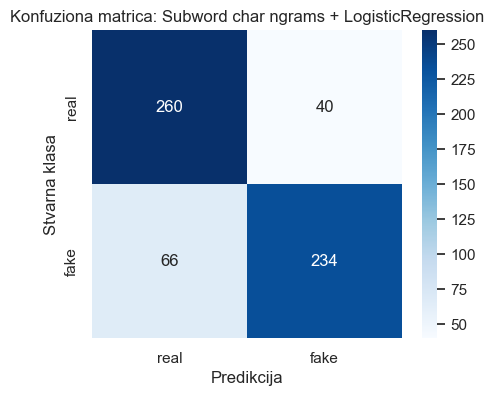

In [33]:
best_result = max(results, key=lambda row: row["f1"])

print("Najbolji eksperiment:", best_result["experiment"])
print("Accuracy:", round(best_result["accuracy"], 4))
print("Precision:", round(best_result["precision"], 4))
print("Recall:", round(best_result["recall"], 4))
print("F1:", round(best_result["f1"], 4))
print()
print(best_result["classification_report"])

plt.figure(figsize=(5, 4))
sns.heatmap(best_result["confusion_matrix"], annot=True, fmt="d", cmap="Blues", xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.title(f"Konfuziona matrica: {best_result['experiment']}")
plt.xlabel("Predikcija")
plt.ylabel("Stvarna klasa")
plt.show()


In [34]:
error_df = df.loc[test_idx, ["job_title", "label", "full_text", "word_count", "lexical_diversity", "typo_proxy_count"]].copy()
error_df["predicted_label"] = pd.Series(best_result["y_pred"], index=test_idx).map({0: "real", 1: "fake"})
error_df["error_type"] = np.where(
    (error_df["label"] == "real") & (error_df["predicted_label"] == "fake"),
    "false_positive",
    np.where(
        (error_df["label"] == "fake") & (error_df["predicted_label"] == "real"),
        "false_negative",
        "correct",
    ),
)

errors = error_df[error_df["error_type"] != "correct"].copy()
errors["snippet"] = errors["full_text"].str.replace("\n", " ", regex=False).str.slice(0, 320)

In [35]:
print("Broj gresaka po tipu:")
display(errors["error_type"].value_counts().to_frame("count"))

Broj gresaka po tipu:


,count
error_type,
false_negative,66
false_positive,40


In [36]:
display(errors[["error_type", "job_title", "label", "predicted_label", "word_count", "lexical_diversity", "typo_proxy_count", "snippet"]].head(8))

,error_type,job_title,label,predicted_label,word_count,lexical_diversity,typo_proxy_count,snippet
2044,false_negative,Financial Reporting Analyst,fake,real,225,0.648889,14,Financial Reporting Analyst The r0le supports ...
2976,false_negative,Software Engineer,fake,real,246,0.638211,5,Software Engineer The position includes a mix ...
2737,false_negative,Sales Operations Associate,fake,real,236,0.665254,6,Sales Operations Associate The role supports a...
2601,false_positive,HR Generalist,real,fake,250,0.644000,7,HR Generalist We are looking for someone who c...
2777,false_negative,Data Analyst,fake,real,195,0.682051,5,Data Analyst The position includes a mix of ro...
2331,false_negative,Operations Coordinator,fake,real,273,0.604396,5,Operations Coordinator The role supports a sma...
2778,false_positive,Software Engineer,real,fake,310,0.638710,13,Software Engineer The position includes a mix ...
1040,false_negative,Product Designer,fake,real,220,0.636364,6,Product Designer Our team works in short plann...


In [37]:
interpret_config = next(config for config in EXPERIMENTS if config["name"] == "TF-IDF stemmed + LogisticRegression")
interpret_result = evaluate_config(interpret_config)
vectorizer = interpret_result["fitted"]["vectorizer"]
model = interpret_result["fitted"]["model"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = model.coef_[0]
top_fake = pd.DataFrame({"token_or_ngram": feature_names[np.argsort(coefs)[-20:][::-1]], "coefficient": np.sort(coefs)[-20:][::-1]})
top_real = pd.DataFrame({"token_or_ngram": feature_names[np.argsort(coefs)[:20]], "coefficient": np.sort(coefs)[:20]})

### 10.1 Vizuelni prikaz najjačih indikatora modela

Grafikoni prikazuju tokene i n-grame koji najviše utiču na odluku interpretabilnog TF-IDF modela. Duža traka označava jači uticaj indikatora na odgovarajuću klasu.

Za realne oglase prikazana je apsolutna jačina negativnih koeficijenata, čime se omogućava direktno poređenje obe grupe indikatora na istoj skali.

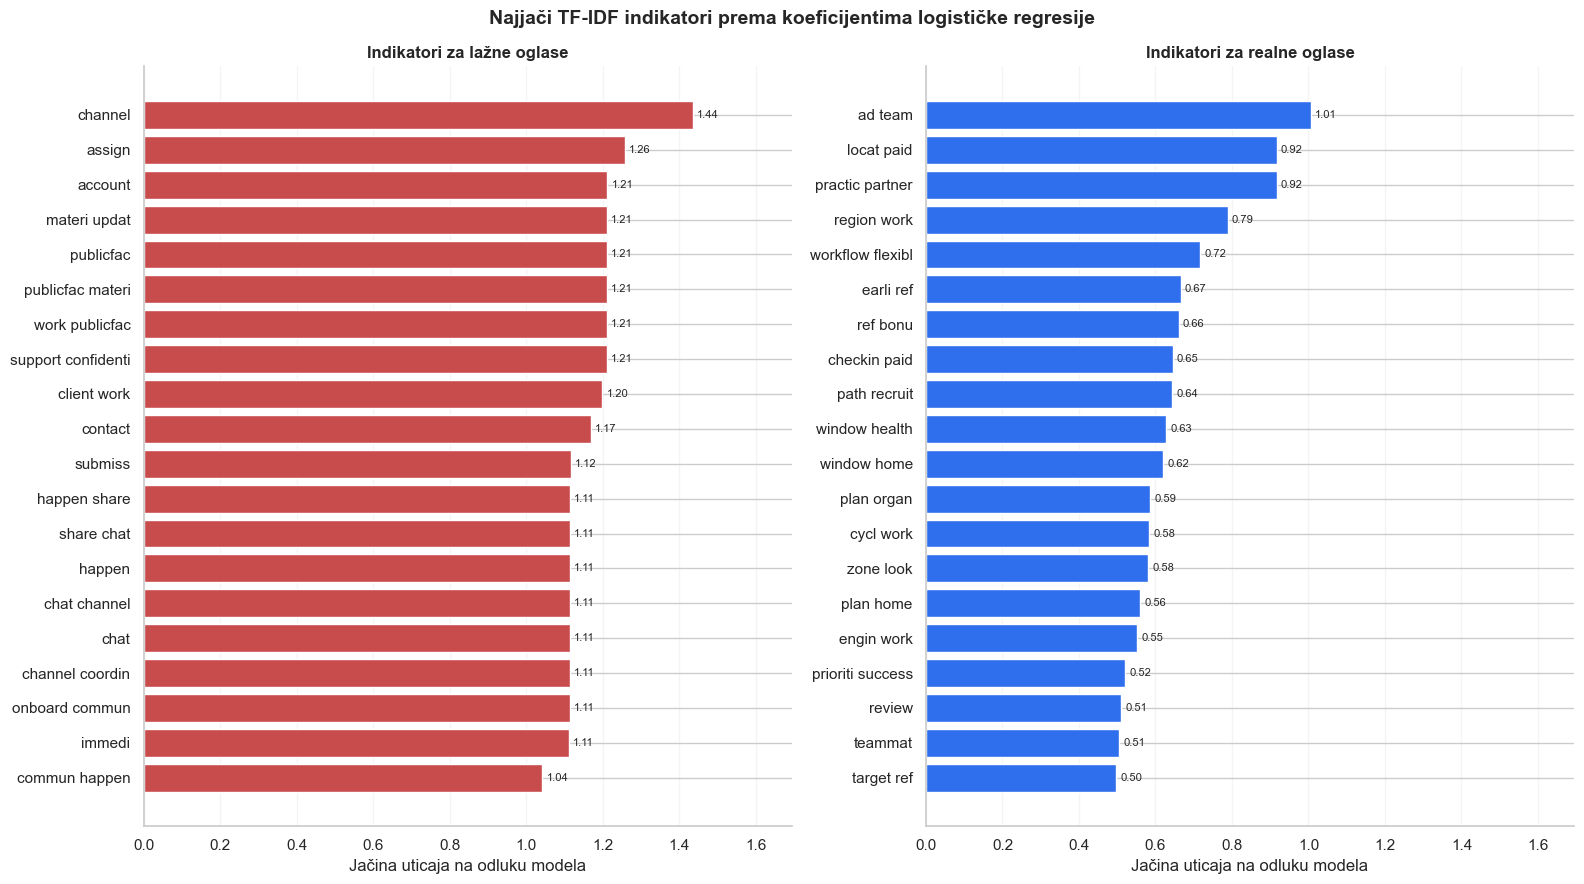

In [38]:
fake_plot = top_fake.sort_values("coefficient", ascending=True).copy()
real_plot = top_real.sort_values("coefficient", ascending=False).copy()
real_plot["strength"] = real_plot["coefficient"].abs()

fig, axes = plt.subplots(1, 2, figsize=(16, 9), sharex=True)

fake_bars = axes[0].barh(
    fake_plot["token_or_ngram"],
    fake_plot["coefficient"],
    color="#C94C4C",
)
axes[0].set_title("Indikatori za lažne oglase", fontweight="bold")
axes[0].set_xlabel("Jačina uticaja na odluku modela")
axes[0].bar_label(fake_bars, fmt="%.2f", padding=3, fontsize=8)

real_bars = axes[1].barh(
    real_plot["token_or_ngram"],
    real_plot["strength"],
    color="#2F6FED",
)
axes[1].set_title("Indikatori za realne oglase", fontweight="bold")
axes[1].set_xlabel("Jačina uticaja na odluku modela")
axes[1].bar_label(real_bars, fmt="%.2f", padding=3, fontsize=8)

max_strength = max(fake_plot["coefficient"].max(), real_plot["strength"].max())
for axis in axes:
    axis.set_xlim(0, max_strength * 1.18)
    axis.grid(axis="x", alpha=0.2)
    axis.set_axisbelow(True)
    axis.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Najjači TF-IDF indikatori prema koeficijentima logističke regresije",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


## 11. Zaključak

Rad pokazuje da kvalitet tekstualnih podataka obuhvata više međusobno povezanih osobina: strukturu i dužinu dokumenata, veličinu rečnika, leksičku raznovrsnost, prisustvo šuma i način predobrade. Normalizacija uklanja površinske razlike u zapisu, dok stemming i lematizacija dodatno grupišu srodne oblike reči.

Poređenje reprezentacija pokazuje da klasični TF-IDF modeli ostaju veoma konkurentni. Character n-gram reprezentacija postiže stabilne rezultate i pokazuje veću otpornost na tipografske i OCR promene, jer koristi delove reči umesto isključivo celih tokena. Word2Vec i FastText prikazuju drugačiji pristup zasnovan na vektorima naučenim iz konteksta, dok DistilBERT omogućava poređenje sa prethodno obučenim jezičkim reprezentacijama.

Kontrolisana augmentacija, testiranje na tekstu sa dodatim šumom, unakrsna validacija i analiza grešaka daju širi kontekst modelskim metrikama. Završni rezultati zato ne pokazuju samo koji model ima najvišu F1 meru, već i kako različite odluke o kvalitetu i reprezentaciji teksta utiču na stabilnost i tumačenje klasifikacije.